In [2]:
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

daily = pd.read_csv('daily_aggregates.csv', parse_dates=['date'])
daily = daily.iloc[30:]  # Remove NaN lags
print(daily.head(5).to_string())

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


         date   revenue  avg_price  num_transactions  num_customers  num_articles  online_pct  day_of_week  month  quarter  week_of_year  is_weekend  year   dow_sin   dow_cos  month_sin     month_cos  is_summer  is_winter  is_holiday_season  rev_roll_mean_7  rev_roll_std_7  rev_roll_min_7  rev_roll_max_7  rev_roll_mean_14  rev_roll_std_14  rev_roll_min_14  rev_roll_max_14  rev_roll_mean_30  rev_roll_std_30  rev_roll_min_30  rev_roll_max_30  rev_ewm_span14  rev_lag1  rev_lag7  rev_lag14  rev_lag30  lag7_mean  lag14_mean  lag7_std  rev_pct_change_1d  rev_pct_change_7d  mtd_revenue  wtd_revenue  rev_rolling_zscore_30  is_rev_outlier_30  rev_stl_trend  rev_stl_seasonal  rev_stl_resid  dept_rev_knitwear  dept_rev_swimwear  dept_rev_trouser  no_sales_day  rev_was_zero
30 2018-10-20  0.323525   0.026960                12             12            12   58.333333            5     10        4            42           1  2018 -0.974928 -0.222521       -1.0 -1.836970e-16          0          0      

In [3]:
daily.shape

(704, 54)

[04:16:38] WARNING: C:/Users/administrator/workspace/xgboost-win64_release_1.6.0/src/learner.cc:627: 
Parameters: { "verbose" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


XGBoost Test R²: 0.9733


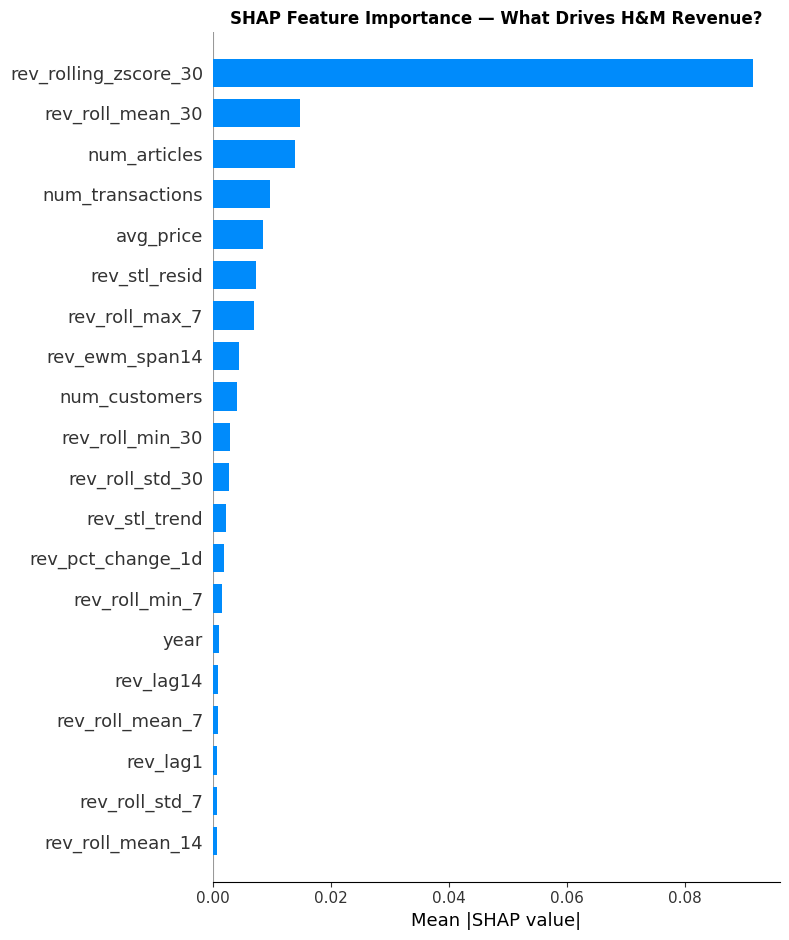


Top 10 Features by SHAP:
              feature  shap_importance
rev_rolling_zscore_30         0.091497
     rev_roll_mean_30         0.014761
         num_articles         0.013908
     num_transactions         0.009690
            avg_price         0.008418
        rev_stl_resid         0.007363
       rev_roll_max_7         0.007006
       rev_ewm_span14         0.004431
        num_customers         0.004158
      rev_roll_min_30         0.002968


In [4]:
# Features (exclude date, target, and leakage)
feature_cols = [c for c in daily.columns if c not in ['date', 'revenue', 'revenue_pct_change']]
X = daily[feature_cols]
y = daily['revenue']

# Time-based split
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Train XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42, verbose=0)
xgb_model.fit(X_train, y_train)

print(f"XGBoost Test R²: {xgb_model.score(X_test, y_test):.4f}")

# SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — What Drives H&M Revenue?', fontweight='bold')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150)
plt.show()

# Get top features
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("\nTop 10 Features by SHAP:")
print(feature_importance.head(10).to_string(index=False))


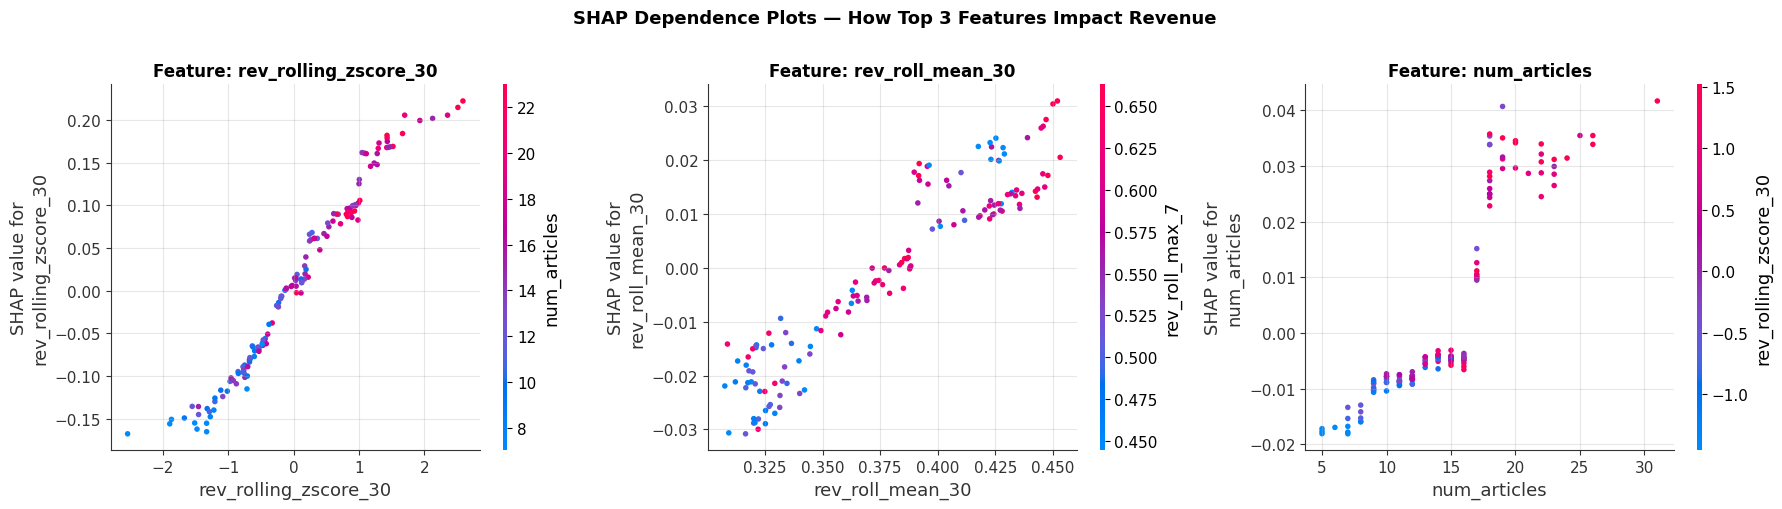

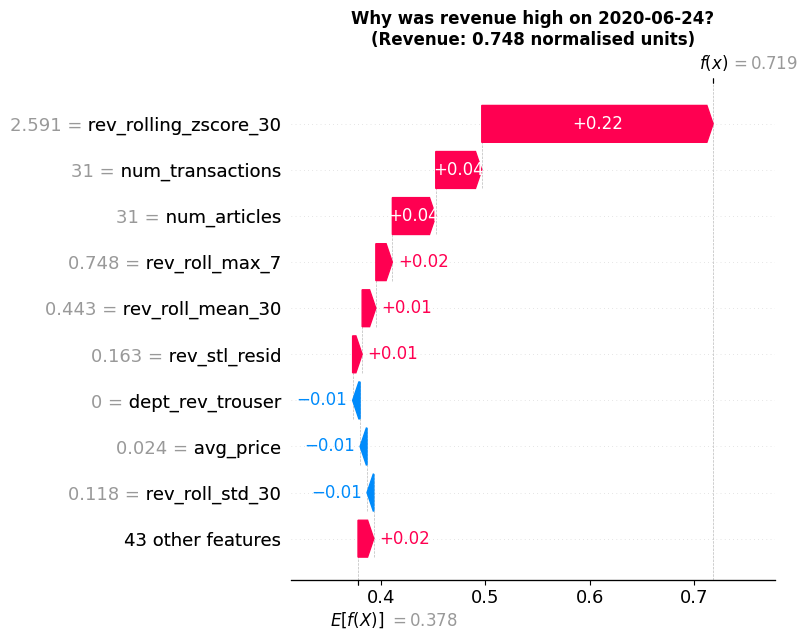

In [5]:
# Dependence plots for top 3 features
top_3 = feature_importance.head(3)['feature'].values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(top_3):
    shap.dependence_plot(feature, shap_values, X_test, ax=axes[idx], show=False)
    axes[idx].set_title(f'Feature: {feature}', fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('SHAP Dependence Plots — How Top 3 Features Impact Revenue', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150)
plt.show()

# Waterfall plot for a high-revenue prediction
high_idx = y_test.values.argmax()

# Get the corresponding date
high_date = daily.loc[X_test.index[high_idx], 'date']
high_revenue = y_test.iloc[high_idx]

plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap.Explanation(values=shap_values[high_idx],
                                     base_values=explainer.expected_value,
                                     data=X_test.iloc[high_idx].values,
                                     feature_names=X_test.columns),
                   show=False)
plt.title(f'Why was revenue high on {high_date.strftime("%Y-%m-%d")}?\n(Revenue: {high_revenue:.3f} normalised units)', 
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150)
plt.show()

In [6]:
print("Generating SHAP exports for Power BI...")

# 1. GLOBAL FEATURE IMPORTANCE (For Bar Charts)
# Calculates the mean absolute SHAP value for each feature
global_shap = pd.DataFrame({
    'Feature_Name': X_test.columns,
    'Mean_Absolute_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values(by='Mean_Absolute_SHAP', ascending=False)

global_shap.to_csv('shap_global_importance.csv', index=False)
print("✅ Saved: shap_global_importance.csv")

# 2. LOCAL FEATURE IMPORTANCE (For Dynamic Time-Series Cross-filtering)
# Get the dates corresponding to the X_test dataset
# (Assuming 'daily' dataframe still has the 'date' column and original index)
if 'date' in daily.columns:
    test_dates = daily.loc[X_test.index, 'date'].values
else:
    test_dates = X_test.index # Fallback if date became the index

# Create a DataFrame of raw SHAP values
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df['Date'] = test_dates

# Melt (Unpivot) the SHAP values into a Long Format (Best practice for Power BI)
shap_melted = shap_df.melt(
    id_vars=['Date'], 
    var_name='Feature_Name', 
    value_name='SHAP_Value'
)

# Extract actual feature values to include as Power BI tooltips
X_test_df = X_test.copy()
X_test_df['Date'] = test_dates
X_melted = X_test_df.melt(
    id_vars=['Date'],
    var_name='Feature_Name',
    value_name='Feature_Value'
)

# Merge SHAP values and Actual Feature values together
shap_for_pbi = pd.merge(shap_melted, X_melted, on=['Date', 'Feature_Name'])

# Export the final unpivoted dataset
shap_for_pbi.to_csv('shap_feature_importance_for_pbi.csv', index=False)
print("✅ Saved: shap_feature_importance_for_pbi.csv")
print("\nPreview of Unpivoted SHAP Data:")
display(shap_for_pbi.head())

Generating SHAP exports for Power BI...
✅ Saved: shap_global_importance.csv
✅ Saved: shap_feature_importance_for_pbi.csv

Preview of Unpivoted SHAP Data:


,Date,Feature_Name,SHAP_Value,Feature_Value
0,2020-05-05,avg_price,0.007538,0.034258
1,2020-05-06,avg_price,0.001657,0.028277
2,2020-05-07,avg_price,0.013125,0.03713
3,2020-05-08,avg_price,0.017035,0.039357
4,2020-05-09,avg_price,0.009148,0.034989


In [7]:
shap_for_pbi.shape

(7332, 4)